# WikiArt Art Movement Classification

**Train a CNN to classify paintings into art movement categories using the WikiArt dataset.**

### 1. Dependencies

In [42]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.image as mpimg
import seaborn as sns

from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

#Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

### 2. Auxiliary Functions

In [43]:
#Count number of image files in each class
def plot_class_distribution(dataset_dir, class_names, title='Class Distribution'):
    counts = []
    image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

    for cls in class_names:
        cls_path = Path(dataset_dir) / cls / cls

        if not cls_path.exists():
            print(f"Warning: missing class folder -> {cls_path}")
            counts.append(0)
            continue

        image_files = [
            p for p in cls_path.iterdir()
            if p.is_file() and p.suffix.lower() in image_extensions]
        counts.append(len(image_files))

    #Sort classes by frequency for easier visual inspection
    sorted_data = sorted(zip(class_names, counts), key=lambda x: x[1], reverse=True)
    class_names_sorted, counts_sorted = zip(*sorted_data)

    print(f'Number of total images: {sum(counts)}')
    print(f'Lowest number of images per class: {min(counts)}')
    print(f'Highest number of images per class: {max(counts)}')

    #Plot horizontal bar chart to highlight class imbalance
    plt.figure(figsize=(10, 6))
    plt.barh(class_names_sorted, counts_sorted)
    plt.xlabel('Number of images')
    plt.title(title)
    plt.tight_layout()
    plt.show()

#Display a few sample images from each selected class
def show_sample_images(dataset_dir, class_names, n_per_class=3):
    fig, axes = plt.subplots(
        len(class_names),
        n_per_class,
        figsize=(n_per_class * 3, len(class_names) * 2.5))

    if len(class_names) == 1:
        axes = np.array([axes])

    image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

    for i, cls in enumerate(class_names):
        cls_path = Path(dataset_dir) / cls / cls

        if not cls_path.exists():
            for j in range(n_per_class):
                axes[i, j].axis('off')
            continue

        image_names = [
            p for p in cls_path.iterdir()
            if p.is_file() and p.suffix.lower() in image_extensions
        ][:n_per_class]

        for j in range(n_per_class):
            axes[i, j].axis('off')

            if j < len(image_names):
                img = mpimg.imread(str(image_names[j]))
                axes[i, j].imshow(img)

            if j == 0:
                axes[i, j].set_title(cls, fontsize=8, fontweight='bold')

    plt.suptitle('Sample Images per Art Movement', fontsize=12)
    plt.tight_layout()
    plt.show()


def process_image_scratch(file_path, label, img_height, img_width):
    #Load image from disk
    img = tf.io.read_file(file_path)

    #Decode image as RGB
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    #Set static shape for TensorFlow graph tracing
    img.set_shape([None, None, 3])

    #Resize image to target dimensions
    img = tf.image.resize(img, [img_height, img_width])

    #Normalize pixel values to [0, 1]
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def process_image_tl(file_path, label, img_height, img_width):
    #Load image from disk
    img = tf.io.read_file(file_path)

    #Decode image as RGB
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    #Set static shape for TensorFlow graph tracing
    img.set_shape([None, None, 3])

    #Resize image to target dimensions
    img = tf.image.resize(img, [img_height, img_width])

    #Keep float32, but do not divide by 255 here
    img = tf.cast(img, tf.float32)
    return img, label

#Build TensorFlow dataset from file paths and labels
def create_dataset(X, y, img_height, img_width, process_fn, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
        ds = ds.shuffle(buffer_size=min(len(X), 5000), seed=seed)

    ds = ds.map(
        lambda file_path, label: process_fn(file_path, label, img_height, img_width),
        num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return ds

#Plot training and validation curves
def plot_accuracy_loss(history): 
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    
    if acc:
        plt.plot(epochs_range, acc, label='Training Accuracy')
    if val_acc:
        plt.plot(epochs_range, val_acc, label='Validation Accuracy')
        
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    
    if val_loss:
        plt.plot(epochs_range, val_loss, label='Validation Loss')
        
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

def print_class_distribution(y, class_names, split_name):
    counter = Counter(y)
    print(f"\n{split_name} distribution:")

    for class_idx, count in sorted(counter.items()):
        class_name = class_names[class_idx]
        print(f"{class_name}: {count}")

#Generate predictions for evaluation
def get_predictions(model, dataset): 
    y_true = []
    y_pred = []

    for images, batch_labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)

        y_true.extend(batch_labels.numpy())
        y_pred.extend(pred_classes)

    return np.array(y_true), np.array(y_pred)

#Plot normalized confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names): 
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(12, 10))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names)
    
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title('Normalised Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 3. Dataset

**Key characteristics:**
- Variable resolution and aspect ratio as paintings come in all shapes and sizes.
- Single-label classification (each image belongs to exactly one movement).
- Significant class imbalance
- Label ambiguity: the boundaries between movements are debated even among experts. The model must learn subtle stylistic differences that humans also find difficult to articulate.

Unlike simpler datasets the present work presents a bigger problem as art movements are defined by style, texture, colour palette and/or brushwork. These are features that are global and subtle, as such, a CNN must learn not just what is in a painting but how it was made. 

#### 3.1 Class Selection

In [44]:
source_dir = Path(r"C:\Users\Inês\.cache\kagglehub\datasets\sivarazadi\wikiart-art-movementsstyles\versions\2")

selected_classes = [
    'Academic_Art',
    'Art_Nouveau',
    'Baroque',
    'Expressionism',
    'Japanese_Art',
    'Neoclassicism',
    'Primitivism',
    'Realism',
    'Renaissance',
    'Rococo',
    'Romanticism',
    'Symbolism',
    'Western_Medieval']

dataset_dir = source_dir
num_classes = len(selected_classes)

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

#Build list of image file paths and integer labels
file_paths = []
labels = []

for label_idx, cls in enumerate(selected_classes):
    class_dir = source_dir / cls / cls

    if not class_dir.exists():
        print(f"Missing source folder for class: {cls}")
        continue

    class_files = [str(p) for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in image_extensions]

    file_paths.extend(class_files)
    labels.extend([label_idx] * len(class_files))

    print(f"{cls}: {len(class_files)} images")

print(f"\nNumber of classes selected: {num_classes}")

Academic_Art: 1305 images
Art_Nouveau: 3035 images
Baroque: 5312 images
Expressionism: 2607 images
Japanese_Art: 2235 images
Neoclassicism: 3115 images
Primitivism: 1324 images
Realism: 5373 images
Renaissance: 6191 images
Rococo: 2521 images
Romanticism: 6813 images
Symbolism: 1510 images
Western_Medieval: 1158 images

Number of classes selected: 13


#### 3.2 Class Distribution and Sample Images

Before building any model, it helps to quickly look at the data to confirm images load correctly and labels are meaningful and check the classes with far fewer images that will likely have lower per-class F1-scores, as knowing this in advance prevents misinterpreting model results.

Number of total images: 42499
Lowest number of images per class: 1158
Highest number of images per class: 6813


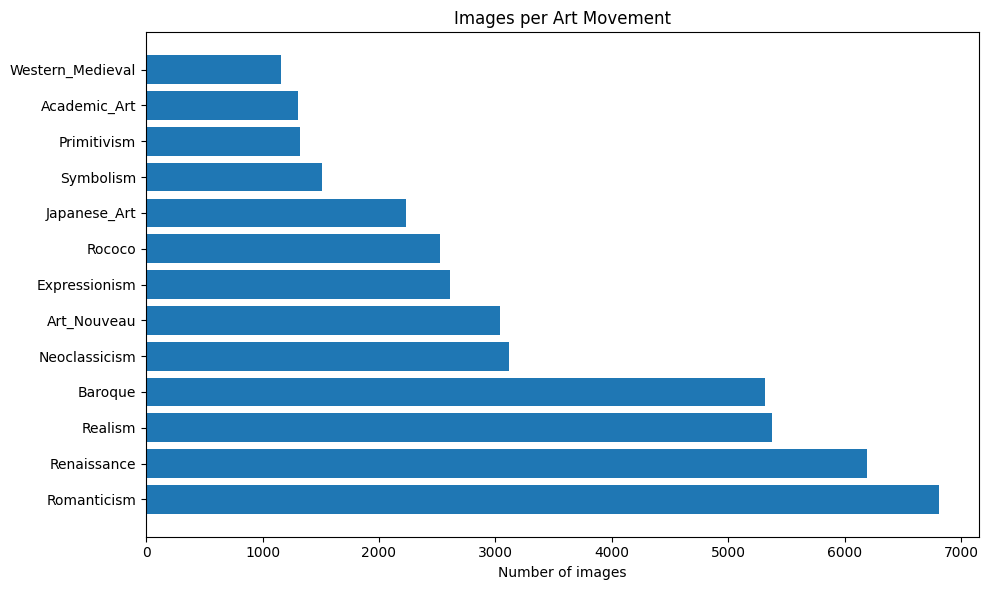

In [45]:
plot_class_distribution(dataset_dir, selected_classes, title='Images per Art Movement')

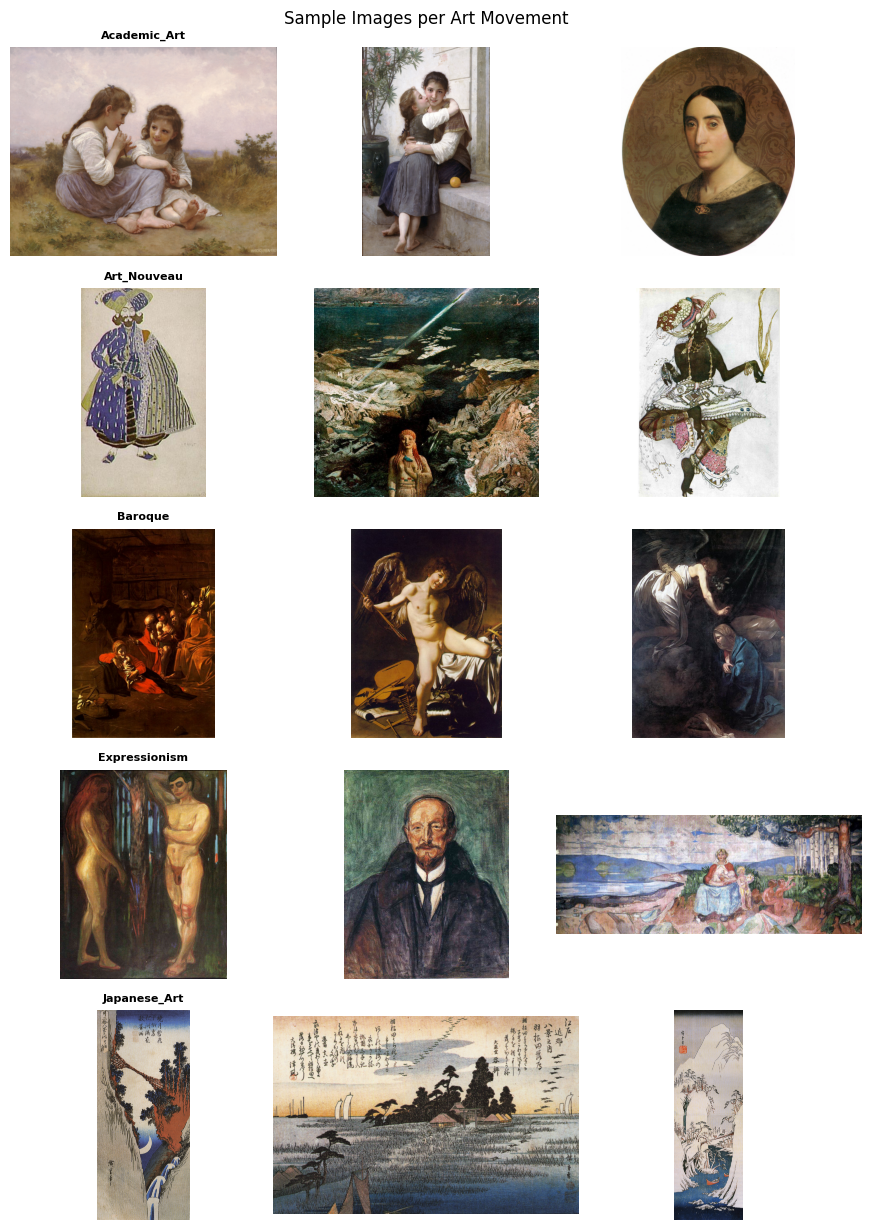

In [46]:
show_sample_images(dataset_dir, selected_classes[:5], n_per_class=3)

### 4. Evaluation Protocol and Data Splits

The dataset is divided into the below non-overlapping subsets.

| Split | Size | Purpose |
|---|---|---|
| Training | 70% | Used to update model weights via gradient descent |
| Validation | 15% | Monitors overfitting during training; never updates weights |
| Test | 15% | Used only once at the very end to report final performance |

**Why hold-out and not K-fold?**  
K-fold cross-validation would be statistically more robust, however, it multiplies training time by K and with around 42,000 images, hold-out is the practical choice. 
Additionally, the validation and test sets are large enough (around 6,000 images each, across 13 classes) that the accuracy estimate has low variance.

**Why stratified splitting?**  
The component `stratify=labels` ensures that the class distribution in each split mirrors the original dataset and is especially important here because the dataset is imbalanced.

**The test set rule:**  
The test set is evaluated exactly once, after all hyperparameter decisions have been made using only the validation set. 
Using test set results to guide model choices constitutes data leakage and produces overoptimistic performance estimates.

#### 4.1 Configuration
The main hyperparameters used throughout the notebook are defined here.

Two input sizes are used:
- For CNNs trained from scratch, images are resized to 96 × 96. This reduces computational cost and allows faster experimentation on a local machine.
- For transfer learning with EfficientNetB0, images are resized to 224 × 224 to match the expected input size of the pre-trained model.

The **batch size is 32**, which is a reasonable compromise between speed and memory usage on a local machine.

In [47]:
#Smaller size for CNNs trained from scratch
img_height_small = 96
img_width_small = 96

#Larger size for transfer learning with EfficientNet
img_height_tl = 224
img_width_tl = 224


batch_size = 32
seed = 42

#### 4.2 Building the Pipeline

Images are loaded and preprocessed using a custom `tf.data.Dataset` pipeline rather than loading everything into memory at once. 

This approach:
- Loads and decodes images on demand (lazy evaluation)
- Applies resizing and normalisation as part of the graph
- Uses `prefetch` so the CPU prepares the next batch while the model trains on the current one

Two preprocessing functions are used:
- For CNNs trained from scratch, pixel values are normalized to [0, 1]
- For transfer learning, images are kept as float32 and passed through the model-specific preprocessing function required by EfficientNet

Additionally, a data cleaning step was performed to remove invalid or corrupted image files that could not be decoded by TensorFlow.

In [48]:
#First split into training and temporary subsets
X_train, X_temp, y_train, y_temp = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=seed)

#Then split into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=seed)

print(f"Training images:   {len(X_train)}")
print(f"Validation images: {len(X_val)}")
print(f"Test images:       {len(X_test)}")

class_weights = compute_class_weight( class_weight='balanced', classes=np.unique(y_train),y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

#Datasets for models trained from scratch
ds_train_small = create_dataset( X_train, y_train,img_height_small, img_width_small,  process_fn=process_image_scratch, training=True)
ds_val_small = create_dataset(X_val, y_val, img_height_small, img_width_small, process_fn=process_image_scratch, training=False)
ds_test_small = create_dataset(X_test, y_test, img_height_small, img_width_small, process_fn=process_image_scratch, training=False)

# Datasets for transfer learning
ds_train_tl = create_dataset(X_train, y_train, img_height_tl, img_width_tl, process_fn=process_image_tl, training=True)
ds_val_tl = create_dataset( X_val, y_val, img_height_tl, img_width_tl, process_fn=process_image_tl, training=False)
ds_test_tl = create_dataset( X_test, y_test, img_height_tl, img_width_tl, process_fn=process_image_tl,training=False)

class_names = selected_classes
print("Class names:", class_names)

Training images:   29749
Validation images: 6375
Test images:       6375
Class weights: {0: np.float64(2.5037030802895135), 1: np.float64(1.0773938867159205), 2: np.float64(0.6154880622336244), 3: np.float64(1.25390937829294), 4: np.float64(1.4631615187881173), 5: np.float64(1.0497177134791813), 6: np.float64(2.4685918181063813), 7: np.float64(0.6084511075205039), 8: np.float64(0.5280075254694544), 9: np.float64(1.2965351928524733), 10: np.float64(0.47984579899027374), 11: np.float64(2.1649807146495887), 12: np.float64(2.821682633026653)}
Class names: ['Academic_Art', 'Art_Nouveau', 'Baroque', 'Expressionism', 'Japanese_Art', 'Neoclassicism', 'Primitivism', 'Realism', 'Renaissance', 'Rococo', 'Romanticism', 'Symbolism', 'Western_Medieval']


#### 4.2.1 Distribution Analysis

In [49]:
print_class_distribution(y_train, selected_classes, "Train")
print_class_distribution(y_val, selected_classes, "Validation")
print_class_distribution(y_test, selected_classes, "Test")


Train distribution:
Academic_Art: 914
Art_Nouveau: 2124
Baroque: 3718
Expressionism: 1825
Japanese_Art: 1564
Neoclassicism: 2180
Primitivism: 927
Realism: 3761
Renaissance: 4334
Rococo: 1765
Romanticism: 4769
Symbolism: 1057
Western_Medieval: 811

Validation distribution:
Academic_Art: 196
Art_Nouveau: 456
Baroque: 797
Expressionism: 391
Japanese_Art: 335
Neoclassicism: 467
Primitivism: 198
Realism: 806
Renaissance: 929
Rococo: 378
Romanticism: 1022
Symbolism: 227
Western_Medieval: 173

Test distribution:
Academic_Art: 195
Art_Nouveau: 455
Baroque: 797
Expressionism: 391
Japanese_Art: 336
Neoclassicism: 468
Primitivism: 199
Realism: 806
Renaissance: 928
Rococo: 378
Romanticism: 1022
Symbolism: 226
Western_Medieval: 174


In [ ]:
for i, cls in enumerate(selected_classes):
    print(f"{cls}: weight={class_weight_dict[i]:.2f}")

#### 4.3 Verify Output

A quick sanity check to confirm the pipeline is producing correctly shaped before any model is built.

In [50]:
#Verify shape and normalization for the small-image pipeline
for images, batch_labels in ds_train_tl.take(1):
    print(f"TL image batch shape: {images.shape}")
    print(f"TL label batch shape: {batch_labels.shape}")
    print(f"TL pixel value range: [{images.numpy().min():.3f}, {images.numpy().max():.3f}]")

TL image batch shape: (32, 224, 224, 3)
TL label batch shape: (32,)
TL pixel value range: [0.000, 255.000]


#### 4.4 Data Augmentation

Data augmentation artificially increases the effective diversity of the training set by applying small random transformations to each image (only during the training).
As such, the validation and test images are kept unchanged, since they should reflect the original data distribution as closely as possible as we want to evaluate on unmodified images.

The transformations used here are deliberately conservative:

- **Small random rotation:** helps simulate slight differences in how paintings may have been photographed or scanned.
- **Random zoom:** makes the model less sensitive to framing and crop differences.
- **Random brightness:** helps account for variation in lighting, scan quality, and digitization conditions.

More aggressive transformations were avoided since they can distort important features in paintings

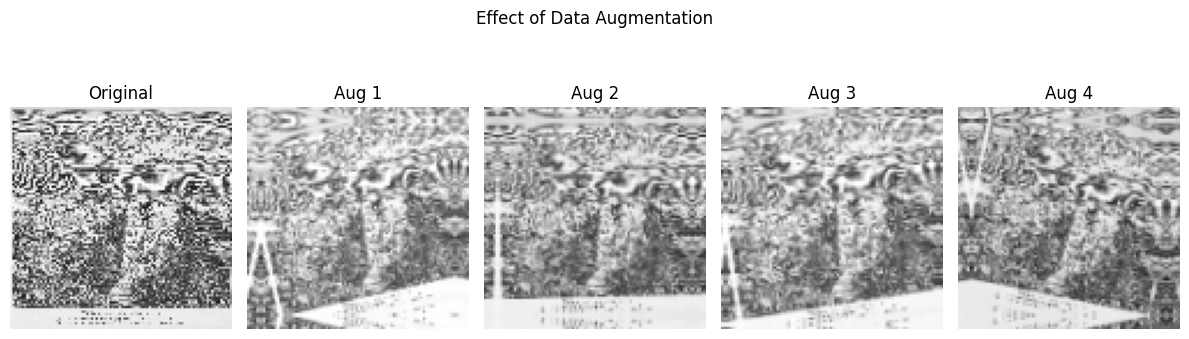

In [ ]:
data_augmentation_scratch = keras.Sequential([
    layers.RandomRotation(0.05, fill_mode='reflect'),
    layers.RandomZoom(0.15, fill_mode='reflect'),
    layers.RandomBrightness(0.1, value_range=(0, 1)),
], name='data_augmentation_scratch')

data_augmentation_tl = keras.Sequential([
    layers.RandomRotation(0.05, fill_mode='reflect'),
    layers.RandomZoom(0.15, fill_mode='reflect'),
], name='data_augmentation_tl')

for images, _ in ds_train_small.take(1):
    plt.figure(figsize=(12, 4))
    first_image = images[0]

    plt.subplot(1, 5, 1)
    plt.imshow(first_image.numpy())
    plt.title('Original')
    plt.axis('off')

    for i in range(4):
        augmented = data_augmentation_scratch(tf.expand_dims(first_image, 0), training=True)
        aug_img = tf.clip_by_value(augmented[0], 0.0, 1.0).numpy()

        plt.subplot(1, 5, i + 2)
        plt.imshow(aug_img)
        plt.title(f'Aug {i+1}')
        plt.axis('off')

    plt.suptitle('Effect of Data Augmentation')
    plt.tight_layout()
    plt.show()

### 5. Modelling

#### 5.1 Baseline Model

The baseline is simple where we have two convolutional blocks followed by a small classifier head. 

The goal in this stage is not to get the best performance, but to:
1. Verify the full pipeline works end to end.
2. Establish a floor that every subsequent model should clearly beat.
3. Demonstrate that even a minimal architecture can learn something above random chance.

`GlobalAveragePooling2D` is used instead of `Flatten` as it dramatically reduces the number of parameters in the dense layers without hurting the convolutional feature extraction, making the baseline faster to train and easier to interpret.

In [54]:
#Baseline CNN with two convolutional blocks
baseline_model = Sequential([
    layers.Input(shape=(img_height_small, img_width_small, 3)),

    layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    #GGlobalAveragePooling keeps the model lightweight
    layers.GlobalAveragePooling2D(),
    #SSmall dense head for initial benchmark
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax', name='output')
], name='baseline')

baseline_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

baseline_model.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,045 (31.43 KB)

 Trainable params: 8,045 (31.43 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
epochs = 10

history_baseline = baseline_model.fit(
    ds_train_small,
    validation_data=ds_val_small,
    epochs=epochs,
    class_weight=class_weight_dict)

Epoch 1/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 171s 181ms/step - accuracy: 0.1367 - loss: 2.4042 - val_accuracy: 0.1641 - val_loss: 2.3547
Epoch 2/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 181s 194ms/step - accuracy: 0.1928 - loss: 2.2473 - val_accuracy: 0.2323 - val_loss: 2.2111
Epoch 3/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 169s 182ms/step - accuracy: 0.2153 - loss: 2.1941 - val_accuracy: 0.2184 - val_loss: 2.2179
Epoch 4/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 176s 189ms/step - accuracy: 0.2307 - loss: 2.1529 - val_accuracy: 0.2372 - val_loss: 2.1968
Epoch 5/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 162s 174ms/step - accuracy: 0.2416 - loss: 2.1192 - val_accuracy: 0.2409 - val_loss: 2.1553
Epoch 6/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 166s 178ms/step - accuracy: 0.2531 - loss: 2.0905 - val_accuracy: 0.2533 - val_loss: 2.1585
Epoch 7/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 193s 207ms/step - accuracy: 0.2665 - loss: 2.0657 - val_accuracy: 0.2696 - val_loss: 2.1104
Epoch 8/10
930/930 ━━━━━━━━━━━━━━━━━━━━ 169s 181ms/step - accuracy: 0.2771 -

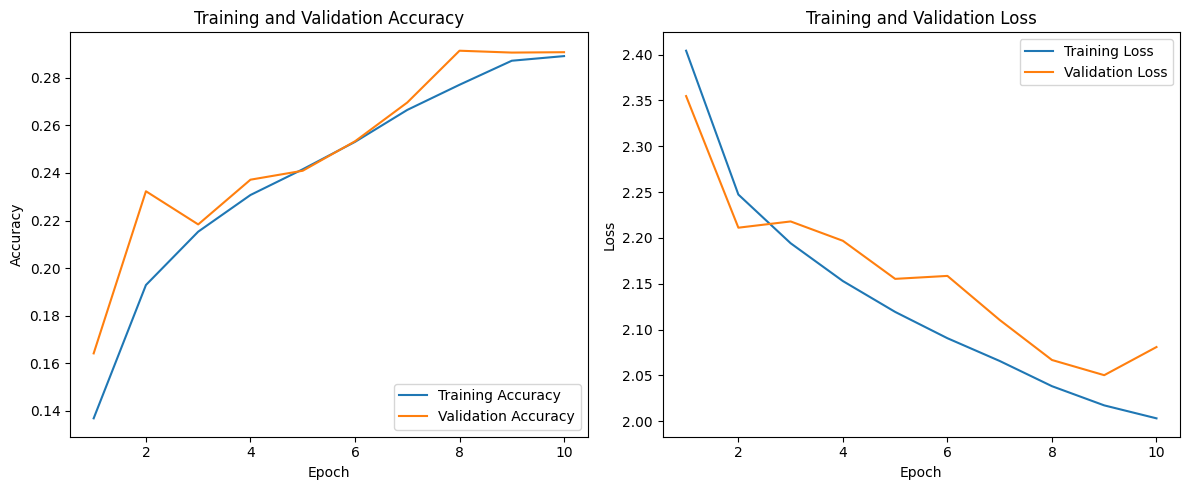

In [56]:
plot_accuracy_loss(history_baseline)

A random classifier, with 13 classes, would achieve approximately 7.7% (1/13 classes) accuracy. 
On the other hand, a majority-class baseline would achieve a higher accuracy due to class imbalance, as it always predicts the most frequent class.

The baseline reaches validation accuracy clearly above random chance, which shows that the model is already learning useful visual patterns from the paintings. At the same time, the training and validation curves remain relatively close, suggesting that this architecture is still too limited to strongly overfit the data. In other words, it works as a baseline, but it is probably not expressive enough to capture the full complexity of the problem.

#### 5.2 Complex Model

The next step is to deliberately make the model larger and harder to regularize. This is useful because, before trying to control overfitting, we first want to verify that the model has enough capacity to overfit in the first place.

**Why force overfitting?**  
1. The model has enough capacity to learn the signal in the data (not just noise)
2. The problem is learnable — there is structure in the WikiArt images that a CNN can extract

If we cannot get a model to overfit, it suggests either the architecture is too small, the learning rate is wrong, or the data pipeline has a problem.

We increase model capacity compared to the baseline by:
- Adding more convolutional blocks (deeper feature extraction)
- Increasing the number of filters per block (wider representations)
- Adding larger dense layers (more parameters in the classifier)
- Training for more epochs to give the model time to memorize training examples

The expected result is a clear divergence between training accuracy (rising) and validation accuracy (plateauing or falling), and between training loss (falling) and validation loss (rising). This divergence is called overfitting.

In [57]:
#Larger CNN designed to overfit the training set
overfit_model = Sequential([
    layers.Input(shape=(img_height_small, img_width_small, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    #Use GAP instead of Flatten to keep training manageable
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax', name='output')
], name='overfit_model')

overfit_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

overfit_model.summary()

Model: "overfit_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,605 (1.35 MB)

 Trainable params: 354,605 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 15

history_overfit = overfit_model.fit(
    ds_train_small,
    validation_data=ds_val_small,
    epochs=epochs)

Epoch 1/15
930/930 ━━━━━━━━━━━━━━━━━━━━ 393s 419ms/step - accuracy: 0.1990 - loss: 2.2749 - val_accuracy: 0.2329 - val_loss: 2.2001
Epoch 2/15
186/930 ━━━━━━━━━━━━━━━━━━━━ 4:56 399ms/step - accuracy: 0.2348 - loss: 2.1789

Class weights were not used in the overfitting experiment, since the goal of this stage was to deliberately maximize model capacity and observe whether the architecture could overfit the training data before introducing balancing or regularization strategies.

In [ ]:
plot_accuracy_loss(history_overfit)

### 6. Regularized Model

After confirming that the larger CNN can overfit, the next step is to regularize it so that it generalizes better to unseen paintings, using three complementary strategies:

**Dropout:**  
Dropout randomly removes part of the network during training (sets a fraction of activations to zero). 
This makes the model rely less on specific neurons and encourages it to learn more robust representations. As such, at inference time all neurons contribute, and their outputs are scaled by (1 - dropout_rate) to maintain the expected activation magnitude.
In practice, stronger dropout is used in the dense part of the network, where overfitting is usually more severe.

We apply lighter dropout (0.2) after convolutional blocks and heavier dropout (0.4) after dense layers as dense layers have far more parameters and are the primary site of memorization, so they receive stronger regularization.

**L2 Weight Regularization:**  
L2 adds a penalty to the loss proportional to the squared magnitude of each weight.
This helps keep the model smoother and discourages extremely specific solutions that only work well on the training set as it discourages the model from learning very large weights, which are characteristic of overfitting.
The penalty coefficient (0.001) is small enough to let the model learn but large enough to keep weights in check.

**Data Augmentation:**  
Augmentation also acts as regularization. By showing slightly modified versions of the same painting during training, the model is pushed to focus on broader stylistic features rather than memorizing exact images.

**Lower learning rate:**  
Once regularization is added, a smaller learning rate usually leads to more stable training. It reduces the risk of unstable updates and helps the model converge more gradually.


To address class imbalance, class weights were computed and applied during training. This penalizes errors in underrepresented classes more heavily and helps the model learn more balanced decision boundaries.

In [ ]:
callbacks_regularized = [
    #Stop training when validation loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True ),
    
    #Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        'best_regularized.keras',
        monitor='val_loss',
        save_best_only=True
    )]

In [ ]:
#Regularized CNN with augmentation, dropout and L2 penalty
regularized_model = Sequential([
    layers.Input(shape=(img_height_small, img_width_small, 3)),
    data_augmentation_scratch,

    layers.Conv2D(
        32, 3, padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)),
    
    layers.MaxPooling2D(),

    layers.Conv2D(
        64, 3, padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)),
    
    layers.MaxPooling2D(),

    layers.Conv2D(
        128, 3, padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)),
    
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    
    layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)),
    
    layers.Dropout(0.3),
    
    layers.Dense(num_classes, activation='softmax')], name='regularized')

regularized_model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss= tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics= ['accuracy'])

regularized_model.summary()

In [ ]:
epochs = 40

history_regularized = regularized_model.fit(
    ds_train_small,
    validation_data=ds_val_small,
    epochs=epochs,
    callbacks=callbacks_regularized,
    class_weight=class_weight_dict)

In [ ]:
plot_accuracy_loss(history_regularized)

### 7. Transfer Learning

The final modelling step is transfer learning. Instead of training all visual features from scratch, we reuse a model that was pre-trained on ImageNet and adapt it to the WikiArt classification task.

This is useful because the first layers of a CNN usually learn very general visual features, such as edges, textures, colour transitions, and simple shapes. Even though ImageNet is very different from an art dataset, those low-level features are still relevant here.

**Why EfficientNetB0?**  
EfficientNetB0 is a good compromise between performance and computational cost. It is much more powerful than the small CNNs built from scratch, but still lightweight enough to be trained on a CPU without becoming completely impractical.

**Strategy used here**  
In this first transfer learning experiment, the EfficientNet base is frozen and only the final classification head is trained. This is the most conservative setup and usually the safest place to start, especially when training resources are limited.

At this stage, the goal is not only to get a better score, but also to compare two very different approaches:
- a CNN trained from scratch on this dataset;
- a pre-trained architecture reused as a feature extractor.

Input images are passed through the EfficientNet preprocessing function before entering the model as this ensures compatibility with the distribution of the data used during pre-training on ImageNet.

In [ ]:
callbacks_transfer = [
    #Stop training when validation loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True),
    
    #Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        'best_transfer.keras',
        monitor='val_loss',
        save_best_only=True
    )]

In [ ]:
#Load EfficientNetB0 pre-trained on ImageNet
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height_tl, img_width_tl, 3))

#Freeze convolutional base
base_model.trainable = False

print(f'Base model layers: {len(base_model.layers)}')
print(f'Trainable variables before unfreezing: {len(base_model.trainable_variables)}')

In [ ]:
#Build transfer learning model on top of frozen EfficientNetB0

inputs = tf.keras.Input(shape=(img_height_tl, img_width_tl, 3))

x = data_augmentation_tl(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

transfer_model = tf.keras.Model(inputs, outputs, name='transfer_efficientnetb0')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])


transfer_model.summary()

In [ ]:
epochs = 20

history_transfer = transfer_model.fit(
    ds_train_tl,
    validation_data=ds_val_tl,
    epochs=epochs,
    callbacks=callbacks_transfer,
    class_weight=class_weight_dict)

In [ ]:
plot_accuracy_loss(history_transfer)

### 8. Model Comparison

We compare the best validation accuracy achieved by each model across the training process. This gives an overview of how each step in the methodology improved performance.

In [ ]:
best_model = transfer_model

In [ ]:
#Compare the best validation accuracy reached by each model
baseline_best = max(history_baseline.history['val_accuracy'])
overfit_best = max(history_overfit.history['val_accuracy'])
regularized_best = max(history_regularized.history['val_accuracy'])
transfer_best = max(history_transfer.history['val_accuracy'])

print(f"Baseline best val accuracy:     {baseline_best:.4f}")
print(f"Overfit model best val accuracy:{overfit_best:.4f}")
print(f"Regularized best val accuracy:  {regularized_best:.4f}")
print(f"Transfer best val accuracy:     {transfer_best:.4f}")

In [ ]:
#Plot best validation accuracy per model
model_names = ['Baseline', 'Overfit', 'Regularized', 'Transfer']
best_scores = [baseline_best, overfit_best, regularized_best, transfer_best]

plt.figure(figsize=(8, 4))
plt.bar(model_names, best_scores)
plt.ylabel('Best validation accuracy')
plt.title('Model comparison')
plt.ylim(0, 1)
plt.show()

In [ ]:
print("Baseline epochs run:", len(history_baseline.history['loss']))
print("Overfit epochs run:", len(history_overfit.history['loss']))
print("Regularized epochs run:", len(history_regularized.history['loss']))
print("Transfer epochs run:", len(history_transfer.history['loss']))

### 9. Evaluation on the Test Set

After all design choices have been made using the training and validation sets, the final step is to evaluate the selected models on the test set.

This is the most important performance estimate in the notebook, because the test set has not been used during model development. The reported results therefore give a more honest measure of how well the model generalises to unseen paintings.

In addition to overall accuracy, the evaluation should also include a confusion matrix and class-level metrics, since some movements are visually much closer to each other than others.

In [ ]:
best_test_ds = ds_test_tl
best_model_name = "Transfer Learning (EfficientNetB0)"

test_loss, test_acc = best_model.evaluate(best_test_ds, verbose=1)
y_true, y_pred = get_predictions(best_model, best_test_ds)

In [ ]:
val_scores = {
    "Baseline": baseline_best,
    "Overfit": overfit_best,
    "Regularized": regularized_best,
    "Transfer": transfer_best}

best_model_name = max(val_scores, key=val_scores.get)
print("Selected model:", best_model_name)

In [ ]:
test_loss, test_acc = best_model.evaluate(ds_test_tl, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

In [ ]:
#Evaluate the selected final model on the appropriate test set
y_true, y_pred = get_predictions(best_model, ds_test_tl)

print(classification_report(y_true, y_pred, target_names=class_names)) 

In [ ]:
plot_confusion_matrix(y_true, y_pred, class_names)

### 10. Utility of the Model

### 11. Future Work